# 2.3 — Régression linéaire et régression logistique

**Navigation** : [<< 2.2-Descente-de-gradient](2.2-Descente-de-gradient.ipynb) | [2.4-Arbres-Forets-Ensembles >>](2.4-Arbres-Forets-Ensembles.ipynb) | [Index](../README.md)

**Kernel** : Python 3

## Introduction

Ce notebook couvre les deux familles de régression canoniques en machine learning. La **régression linéaire** prédit un nombre **continu** (un prix, une température) et est ajustée par la méthode des **moindres carrés** (OLS). La **régression logistique** prédit une **probabilité** pour une classe binaire (spam / non-spam) et est ajustée par le **maximum de vraisemblance** (MLE). Les deux sont des modèles linéaires, mais ils répondent à des tâches différentes et utilisent des métriques différentes.

### Objectifs d'apprentissage

À la fin de ce notebook, vous saurez :
1. Ajuster une régression linéaire et lire le coefficient de détermination R² ainsi que les résidus.
2. Ajuster une régression logistique, comprendre la fonction sigmoid et le seuil de décision.
3. Contraster les deux principes d'estimation : OLS (moindres carrés) vs MLE (maximum de vraisemblance).
4. Interpréter les coefficients de chaque modèle (pente vs odds ratio).

### Prérequis

- Notebook 2.1 (métriques d'évaluation).
- Notebook 2.2 (descente de gradient).
- Notion de base en probabilités.

> **Référence.** Nelder, J.A. & Wedderburn, R.W.M. (1972), *Generalized Linear Models*, Journal of the Royal Statistical Society. Series A 135(3):370-384. Ce cadre unifie régression linéaire (gaussienne) et logistique (binomiale) comme modèles linéaires généralisés, chacun avec sa fonction de lien et son estimation.

In [1]:
# Configuration : imports et graine aleatoire
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression, make_classification
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Graine pour la reproductibilite
np.random.seed(42)

print("Configuration OK : 2.3 - Regression lineaire et logistique")

Configuration OK : 2.3 - Regression lineaire et logistique


## 1. Régression linéaire : prédire une valeur continue

La régression linéaire modélise la cible continue $y$ comme une combinaison linéaire des variables explicatives :

$$y = w_1 x_1 + w_2 x_2 + \dots + w_p x_p + b = \mathbf{w} \cdot \mathbf{x} + b$$

Le modèle est ajusté en **minimisant la somme des carrés des résidus** (Ordinary Least Squares, OLS) :

$$\min_{w, b} \sum_i (y_i - (\mathbf{w} \cdot \mathbf{x}_i + b))^2$$

La qualité de l'ajustement se mesure par le **coefficient de détermination R²** : la proportion de la variance de $y$ expliquée par le modèle (entre 0 et 1, 1 étant parfait).

In [2]:
# Generation de donnees de regression (3 variables explicatives, bruit modere)
X, y = make_regression(n_samples=200, n_features=3, noise=25.0, bias=5.0, random_state=42)

# Separation en jeu d'entrainement et de test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Ajustement du modele de regression lineaire par moindres carres (OLS)
modele_lineaire = LinearRegression().fit(X_train, y_train)

# Prediction sur le jeu de test
y_pred = modele_lineaire.predict(X_test)

# Affichage des coefficients et de la qualite (R^2)
print("Coefficients (pentes) :", modele_lineaire.coef_)
print("Ordonnee a l'origine (biais) :", modele_lineaire.intercept_)
print("R^2 sur le jeu de test :", r2_score(y_test, y_pred))

Coefficients (pentes) : [71.71064149 21.96838218 72.87345924]
Ordonnee a l'origine (biais) : 3.408876242728427
R^2 sur le jeu de test : 0.9117475179470665


## 2. R² et résidus

Le **R²** se lit ainsi :
- **R² = 1** : ajustement parfait.
- **R² = 0** : le modèle ne fait pas mieux que prédire systématiquement la moyenne de $y$.
- **R² < 0** : le modèle est pire que la moyenne (modèle mal spécifié).

Les **résidus** sont les erreurs $e_i = y_i^{vrai} - y_i^{predit}$. Pour un bon modèle linéaire, les résidus sont **centrés sur zéro** et ne présentent **aucune structure visible** (ni courbe, ni entonnoir). Un motif dans les résidus (par exemple une forme en U) indique que le modèle passe à côté d'une relation non linéaire.

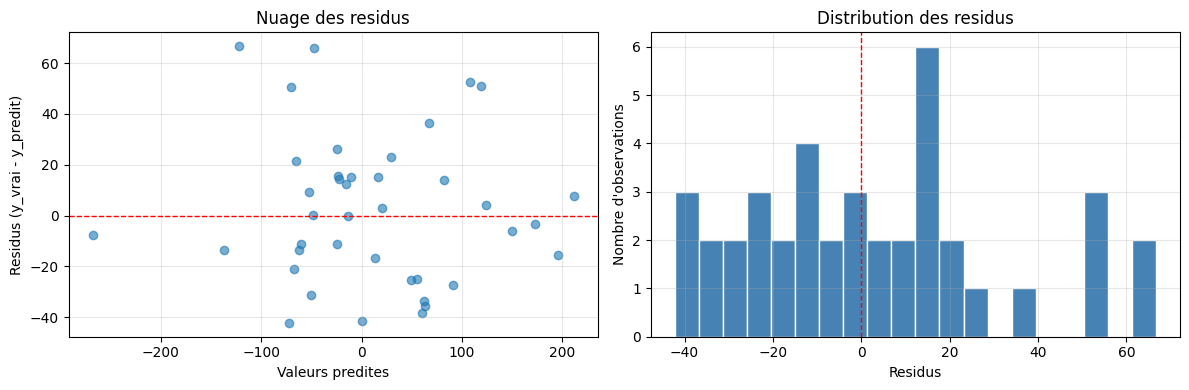

In [3]:
# Calcul des residus sur le jeu de test
residus = y_test - y_pred

# Figure : nuage des residus + histogramme
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Nuage : valeurs predites vs residus (doit etre centre sur 0, sans structure)
axes[0].scatter(y_pred, residus, alpha=0.6)
axes[0].axhline(0, color="red", linestyle="--", linewidth=1)
axes[0].set_xlabel("Valeurs predites")
axes[0].set_ylabel("Residus (y_vrai - y_predit)")
axes[0].set_title("Nuage des residus")
axes[0].grid(alpha=0.3)

# Histogramme : doit etre centre sur 0, approximativement symetrique
axes[1].hist(residus, bins=20, color="steelblue", edgecolor="white")
axes[1].axvline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_xlabel("Residus")
axes[1].set_ylabel("Nombre d'observations")
axes[1].set_title("Distribution des residus")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# A lire : residus centres sur 0, pas de courbe ni d'entonnoir visible.

### Exercice 1 : calculer et interpréter R² à la main

**Objectif** : calculer le coefficient de détermination R² directement à partir de sa définition, puis le comparer à la valeur renvoyée par `r2_score` de scikit-learn.

La formule du R² est :

$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}}, \quad SS_{res} = \sum_i (y_i - \hat{y}_i)^2, \quad SS_{tot} = \sum_i (y_i - \bar{y})^2$$

où $\bar{y}$ est la moyenne des valeurs observées sur le jeu de test.

**Indice** :
- `SS_res` se calcule avec `np.sum((y_test - y_pred)**2)`.
- Pour `SS_tot`, remplacez `y_pred` par la moyenne `np.mean(y_test)`.

In [4]:
# Exercice 1 : calculer R^2 a la main (1 - SS_res / SS_tot)
# TODO etudiant : calculer SS_res et SS_tot sur le jeu de test
SS_res = None  # TODO etudiant : remplacer (somme des carres des residus)
SS_tot = None  # TODO etudiant : remplacer (somme des ecarts a la moyenne)
r2_manuel = None  # TODO etudiant : remplacer (1 - SS_res / SS_tot)
print(f"Exercice 1 a completer : R^2 manuel = {r2_manuel}")

Exercice 1 a completer : R^2 manuel = None


## 3. Interpréter les coefficients

Chaque coefficient $w_j$ mesure de combien varie $y$ lorsque la variable $x_j$ **augmente d'une unité**, toutes les autres variables étant maintenues constantes :
- le **signe** indique le sens (positif ou négatif) ;
- la **magnitude** indique l'ampleur de l'effet.

**Attention** : la magnitude dépend de l'échelle de la variable. Pour comparer l'importance relative de plusieurs variables, il faut les **standardiser** (même échelle) au préalable, sinon une variable exprimée en milliers paraîtra artificiellement plus influente qu'une variable exprimée en unités.

In [5]:
# Tableau des coefficients tries par valeur absolue decroissante
coefs_df = pd.DataFrame({
    "variable": [f"x{j}" for j in range(X.shape[1])],
    "coefficient": modele_lineaire.coef_,
})
coefs_df["valeur_absolue"] = coefs_df["coefficient"].abs()
coefs_df = coefs_df.sort_values("valeur_absolue", ascending=False).reset_index(drop=True)

print(coefs_df[["variable", "coefficient"]])
# Interpretation : la variable en tete a le plus grand impact (en valeur absolue)
# sur la cible y, une unite supplementaire de cette variable modifie y d'environ
# la valeur de son coefficient.

  variable  coefficient
0       x2    72.873459
1       x0    71.710641
2       x1    21.968382


## 4. Régression logistique : prédire une probabilité binaire

Changement de tâche : nous passons à la **classification**. La régression logistique modélise la **probabilité** d'appartenir à la classe 1 :

$$p = \sigma(\mathbf{w} \cdot \mathbf{x} + b) = \frac{1}{1 + e^{-(\mathbf{w} \cdot \mathbf{x} + b)}}$$

La fonction **sigmoid** $\sigma$ écrase n'importe quel score réel dans l'intervalle $(0, 1)$. Contrairement à la régression linéaire, l'ajustement se fait par **maximum de vraisemblance** (MLE) et non par moindres carrés : on cherche les paramètres qui rendent les labels observés les plus probables.

> **Référence.** Cox, D.R. (1958), *The Regression Analysis of Binary Sequences*, Journal of the Royal Statistical Society. Series B (Methodological) 20(2):215-232. La régression logistique (modèle logit) y est introduite pour les réponses binaires — l'estimation se fait par maximum de vraisemblance, non par moindres carrés.

In [6]:
# Generation de donnees de classification binaire (4 variables, 3 informatives)
Xc, yc = make_classification(n_samples=300, n_features=4, n_informative=3,
                             n_redundant=0, flip_y=0.08, random_state=42)

# Separation en jeu d'entrainement et de test (80/20)
Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.2, random_state=42)

# Ajustement du modele de regression logistique (max_iter augmente pour la convergence)
modele_logistique = LogisticRegression(max_iter=1000).fit(Xc_train, yc_train)

# Probabilites predites sur quelques points du jeu de test (colonnes : P(classe 0), P(classe 1))
proba_exemple = modele_logistique.predict_proba(Xc_test[:5])
print("Probabilites predites (5 premiers points de test) :")
print("Colonne 0 = P(classe 0), Colonne 1 = P(classe 1)")
print(proba_exemple)

Probabilites predites (5 premiers points de test) :
Colonne 0 = P(classe 0), Colonne 1 = P(classe 1)
[[0.6793738  0.3206262 ]
 [0.84864255 0.15135745]
 [0.88463587 0.11536413]
 [0.01185721 0.98814279]
 [0.6753429  0.3246571 ]]


## 5. La fonction sigmoid

La sigmoid transforme le **score linéaire** $z = \mathbf{w} \cdot \mathbf{x} + b$ en une **probabilité** comprise dans $(0, 1)$ :

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Le **seuil de décision** par défaut est **0,5** : si $p \geq 0,5$, on prédit la classe 1, sinon la classe 0. La courbe a la forme en S caractéristique : autour de $z = 0$, la probabilité vaut 0,5 et la décision est la plus incertaine.

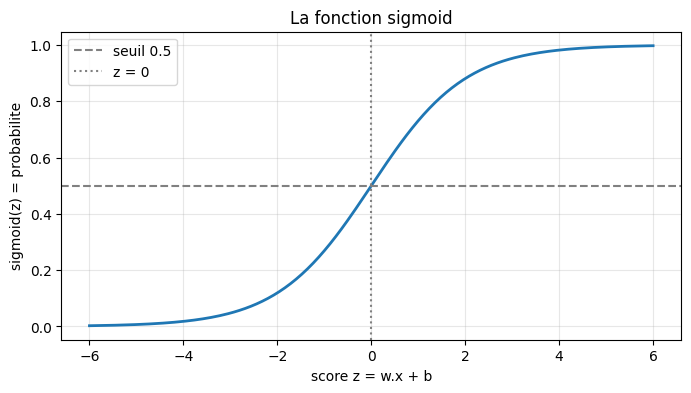

In [7]:
# Visualisation de la fonction sigmoid
z = np.linspace(-6, 6, 200)
p = 1 / (1 + np.exp(-z))

plt.figure(figsize=(8, 4))
plt.plot(z, p, linewidth=2)
plt.axhline(0.5, linestyle="--", color="gray", label="seuil 0.5")
plt.axvline(0, linestyle=":", color="gray", label="z = 0")
plt.xlabel("score z = w.x + b")
plt.ylabel("sigmoid(z) = probabilite")
plt.title("La fonction sigmoid")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
# A lire : la courbe en S ecrase les scores extremes vers 0 et 1,
# et coupe 0.5 exactement en z = 0.

## 6. OLS vs MLE : deux principes d'estimation

C'est le contraste conceptuel clé de ce notebook :

| Aspect | Régression linéaire (OLS) | Régression logistique (MLE) |
|--------|---------------------------|------------------------------|
| Cible | continue | binaire (0/1) |
| Principe | minimiser l'erreur quadratique | maximiser la vraisemblance |
| Solution | forme fermée (analytique) | pas de forme fermée (descente de gradient / IRLS) |
| Sortie | valeur réelle | probabilité dans (0, 1) |

Les deux modèles partagent le même **cœur linéaire** ($\mathbf{w} \cdot \mathbf{x} + b$), mais le principe d'estimation diffère radicalement. Tous deux sont des cas particuliers de **modèles linéaires généralisés** (GLM).

> **Référence.** Hastie, T., Tibshirani, R. & Friedman, J. (2009), *The Elements of Statistical Learning*, Springer (2e éd.), sections 4.2-4.4. La distinction entre estimation par moindres carrés (OLS) et par maximum de vraisemblance (MLE) y est posée comme le principe fondateur du choix de modèle.

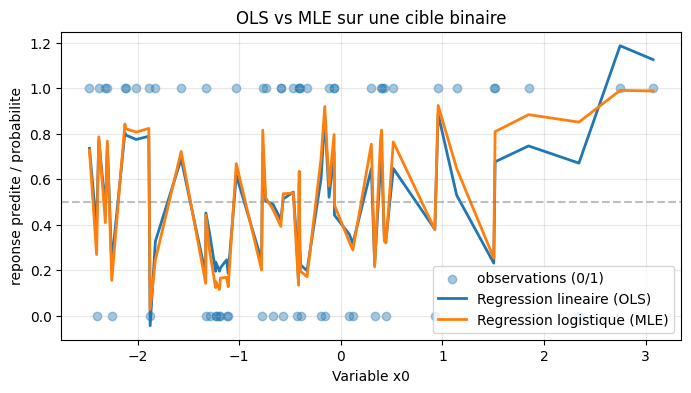

In [8]:
# Comparaison : regression lineaire vs logistique sur les MEMES donnees binaires
# On utilise la premiere variable explicative pour la visualisation
feature_idx = 0
x_visu = Xc_test[:, feature_idx]
ordre = np.argsort(x_visu)
x_visu_trie = x_visu[ordre]

# Ajustement d'une regression lineaire sur les labels 0/1 (illustratif, "mal adapte")
modele_lin_binaire = LinearRegression().fit(Xc_train, yc_train)
pred_lineaire = modele_lin_binaire.predict(Xc_test)[ordre]

# Probabilites de la regression logistique
pred_logistique = modele_logistique.predict_proba(Xc_test)[:, 1][ordre]

plt.figure(figsize=(8, 4))
plt.scatter(x_visu, yc_test, alpha=0.4, label="observations (0/1)")
plt.plot(x_visu_trie, pred_lineaire, label="Regression lineaire (OLS)", linewidth=2)
plt.plot(x_visu_trie, pred_logistique, label="Regression logistique (MLE)", linewidth=2)
plt.axhline(0.5, linestyle="--", color="gray", alpha=0.5)
plt.xlabel(f"Variable x{feature_idx}")
plt.ylabel("reponse predite / probabilite")
plt.title("OLS vs MLE sur une cible binaire")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
# A lire : la courbe logistique est bornee entre 0 et 1 (forme en S),
# tandis que la droite lineaire depasse 1 et descend sous 0.
# C'est precisement pour cela que la regression logistique existe.

### Exercice 2 : le seuil de décision change les prédictions

**Objectif** : prédire les classes à l'aide d'un **seuil personnalisé** (par exemple 0,3 au lieu du seuil par défaut 0,5) à partir des probabilités prédites, puis compter combien de prédictions changent par rapport au seuil standard.

Baisser le seuil (ex. 0,3) rend le modèle plus **sensible** : il classe plus d'observations en classe 1. L'augmenter (ex. 0,7) le rend plus **spécifique**.

**Indice** : la conversion probabilité → classe s'écrit `(proba >= seuil).astype(int)`. Comparez ensuite au résultat du seuil 0,5 pour compter les changements.

In [9]:
# Exercice 2 : predire les classes avec un seuil personnalise (ex 0.3)
proba_test = modele_logistique.predict_proba(Xc_test)[:, 1]  # proba de classe 1
seuil = None  # TODO etudiant : choisir un seuil (ex 0.3 ou 0.7)
# TODO etudiant : predire les classes avec ce seuil
classes_seuil = None  # TODO etudiant : remplacer ((proba_test >= seuil).astype(int))
# TODO etudiant : nombre de predictions differentes du seuil par defaut 0.5
nb_changements = None  # TODO etudiant : remplacer
print(f"Exercice 2 a completer : seuil={seuil}, nb predictions changees = {nb_changements}")

Exercice 2 a completer : seuil=None, nb predictions changees = None


## 7. Interprétation des coefficients logistiques

En régression logistique, un coefficient $w_j$ modifie les **log-odds** d'une quantité $w_j$ par unité de $x_j$. La quantité directement interprétable est l'**odds ratio** :

$$\text{odds ratio}_j = e^{w_j}$$

Il représente l'effet **multiplicatif** sur la cote (odds) d'appartenir à la classe 1 :
- $\text{odds ratio} > 1$ : la variable **augmente** la probabilité de la classe 1.
- $\text{odds ratio} < 1$ : la variable **diminue** cette probabilité.
- $\text{odds ratio} = 1$ : aucun effet.

Par exemple, un odds ratio de 2 signifie que chaque unité supplémentaire de la variable **double** la cote d'être en classe 1.

In [10]:
# Calcul des odds ratios = exp(coefficient) pour la regression logistique
odds_ratios = np.exp(modele_logistique.coef_[0])
or_df = pd.DataFrame({
    "variable": [f"x{j}" for j in range(Xc.shape[1])],
    "coefficient_logistique": modele_logistique.coef_[0],
    "odds_ratio": odds_ratios,
})
print(or_df)
# Interpretation : une variable dont l'odds ratio vaut 2 double la cote de
# la classe 1 pour chaque unite supplementaire ; un odds ratio de 0.5 la divise par 2.

  variable  coefficient_logistique  odds_ratio
0       x0                0.590224    1.804393
1       x1                0.090039    1.094217
2       x2                0.882871    2.417831
3       x3                0.221179    1.247547


### Exercice 3 : interpréter le odds ratio

**Objectif** : identifier la variable qui a le plus grand effet (en valeur relative) sur la probabilité d'appartenir à la classe 1, puis interpréter concrètement sa valeur.

**Étape 1** : calculez les odds ratios `np.exp(modele_logistique.coef_[0])`.
**Étape 2** : repérez l'indice de la variable dont l'odds ratio est le plus grand (le plus éloigné au-dessus de 1).
**Étape 3** : interprétez : « chaque unité supplémentaire de cette variable multiplie la cote de la classe 1 par ... ».

In [11]:
# Exercice 3 : identifier la feature avec le plus grand odds ratio
odds_ratios = None  # TODO etudiant : remplacer (np.exp des coefficients logistiques)
# TODO etudiant : trouver l'indice de la feature avec le plus grand odds ratio
indice_max = None  # TODO etudiant : remplacer
valeur_max = None  # TODO etudiant : remplacer
print(f"Exercice 3 a completer : feature {indice_max} a le plus grand odds ratio = {valeur_max}")

Exercice 3 a completer : feature None a le plus grand odds ratio = None


## Conclusion et transition

Ce notebook a couvert les deux familles de régression canoniques :

| Modèle | Cible | Estimation | Métriques / lecture |
|--------|-------|------------|---------------------|
| Régression linéaire | continue | OLS (moindres carrés) | R², résidus centrés |
| Régression logistique | binaire | MLE (maximum de vraisemblance) | sigmoid, odds ratios |

Les deux partagent le même cœur linéaire ($\mathbf{w} \cdot \mathbf{x} + b$), mais la tâche (continu vs binaire) et le principe d'estimation (OLS vs MLE) diffèrent. Savoir choisir entre les deux selon la nature de la cible est une compétence fondatrice.

Le prochain notebook (`2.4-Arbres-Forets-Ensembles`) quitte les modèles linéaires pour les arbres de décision et les méthodes d'ensemble, qui capturent des relations non linéaires.

## References

1. Nelder, J.A. & Wedderburn, R.W.M. (1972). *Generalized Linear Models*. Journal of the Royal Statistical Society. Series A 135(3):370-384. — Le cadre unifiant régression linéaire (gaussienne) et logistique (binomiale).
2. Cox, D.R. (1958). *The Regression Analysis of Binary Sequences*. Journal of the Royal Statistical Society. Series B (Methodological) 20(2):215-232. — La régression logistique, estimation par maximum de vraisemblance.
3. Hastie, T., Tibshirani, R. & Friedman, J. (2009). *The Elements of Statistical Learning*. Springer (2e éd.), §4.2-4.4. — OLS vs MLE comme principes d'estimation.
4. Hosmer, D.W., Lemeshow, S. & Sturdivant, R.X. (2013). *Applied Logistic Regression*. Wiley (3e éd.). — Interprétation des coefficients et des odds ratios.
5. Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python*. Journal of Machine Learning Research 12:2825-2830. — `LinearRegression`, `LogisticRegression`, métriques.